In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"E:\Bahare (important)\uni\Master\Data Visualization Project\Grok 2\customer_shopping_data.csv")

In [3]:
# Total revenue = quantity * price
df['total_price'] = df['quantity'] * df['price']

In [4]:
# Group by category
cat_rev = df.groupby('category')['total_price'].sum().sort_values(ascending=False) / 1_000_000  # میلیون TL
cat_count = df.groupby('category').size()

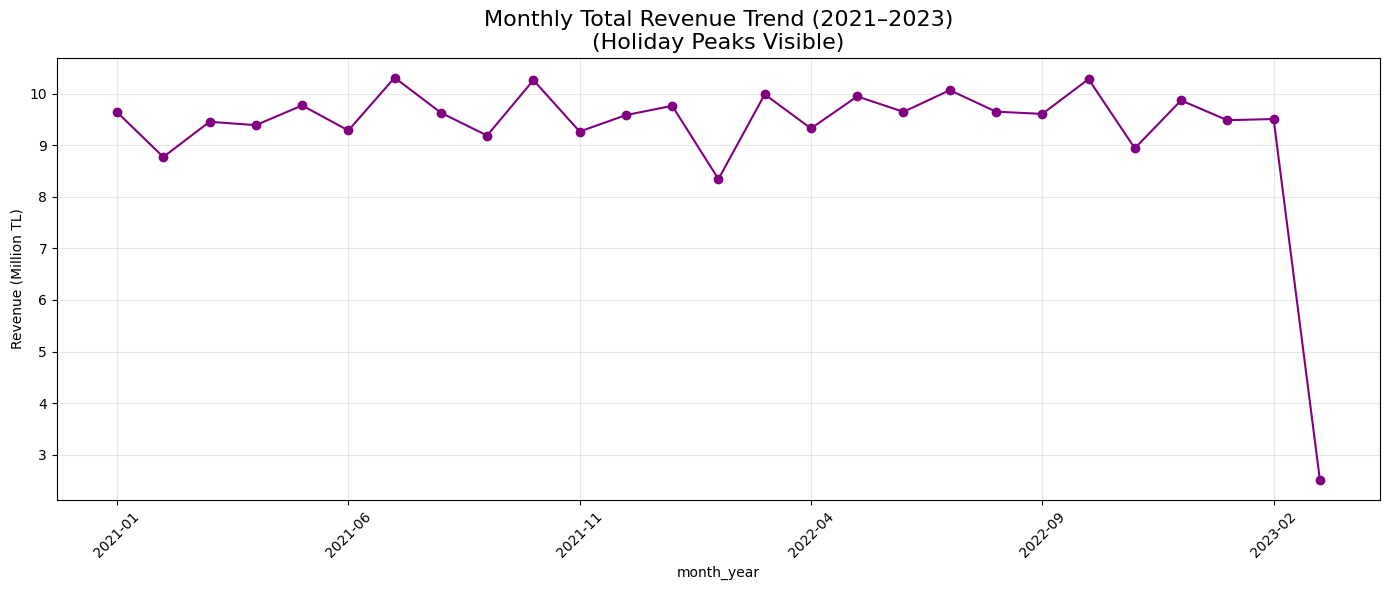

In [8]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df['month_year'] = df['invoice_date'].dt.strftime('%Y-%m')

monthly_sales = df.groupby('month_year')['total_price'].sum() / 1_000_000

plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Total Revenue Trend (2021–2023)\n(Holiday Peaks Visible)', fontsize=16)
plt.ylabel('Revenue (Million TL)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300)
plt.show()

In [ ]:
df['total_price'] = df['quantity'] * df['price']
mall_revenue = df.groupby('shopping_mall')['total_price'].sum() / 1_000_000  # per million
mall_revenue = mall_revenue.sort_values(ascending=False).round(1)
mall_revenue

shopping_mall
Mall of Istanbul     50.9
Kanyon               50.6
Metrocity            37.3
Metropol AVM         25.4
Istinye Park         24.6
Zorlu Center         12.9
Cevahir AVM          12.6
Viaport Outlet       12.5
Emaar Square Mall    12.4
Forum Istanbul       12.3
Name: total_price, dtype: float64

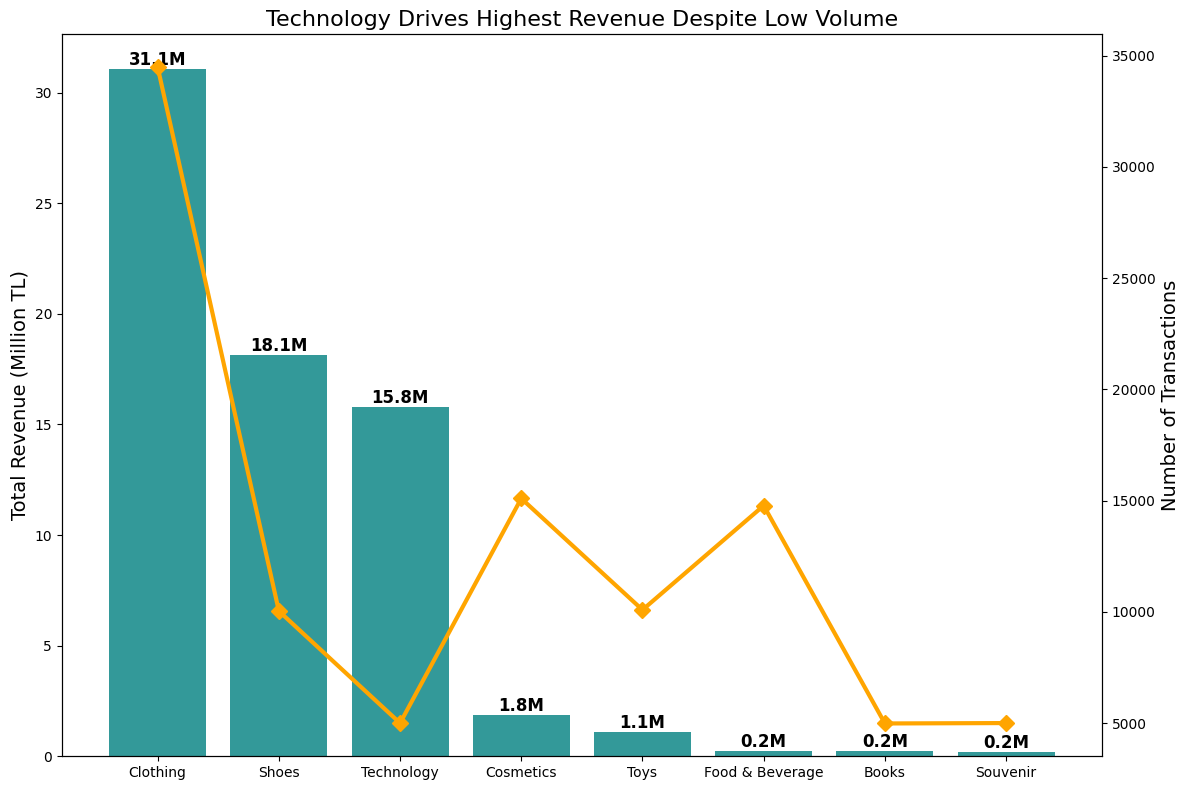

In [6]:

cat_rev = df.groupby('category')['price'].sum().sort_values(ascending=False) / 1_000_000
cat_count = df.groupby('category').size().reindex(cat_rev.index)  

fig, ax1 = plt.subplots(figsize=(12, 8))
bars = ax1.bar(cat_rev.index, cat_rev.values, color='teal', alpha=0.8)
ax1.set_ylabel('Total Revenue (Million TL)', fontsize=14)
ax1.set_title('Technology Drives Highest Revenue Despite Low Volume', fontsize=16)

ax2 = ax1.twinx()
ax2.plot(cat_count.index, cat_count.values, color='orange', marker='D', linewidth=3, markersize=8)
ax2.set_ylabel('Number of Transactions', fontsize=14)

plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}M', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0,3), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('category_revenue_improved.png', dpi=300)
plt.show()